In [1]:
from pathlib import Path
import jax.numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# plt.rc('text', usetex=True)
# plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [3]:
n = 30
shape = (n, n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(20, 5000, n)
src_pos_array = np.geomspace(0.02, 0.99, n)
dL_array = np.geomspace(0.1, 10, n)

# Make grid
R_orbit_mesh, src_pos_mesh, dL_mesh = np.meshgrid(R_orbit_array, src_pos_array, dL_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh
events['src_pos'] = src_pos_mesh
events['dL'] = dL_mesh

Text(0.5, 1.0, 'SNR for HLV Network at $d_L$ = 0.10 Gpc')

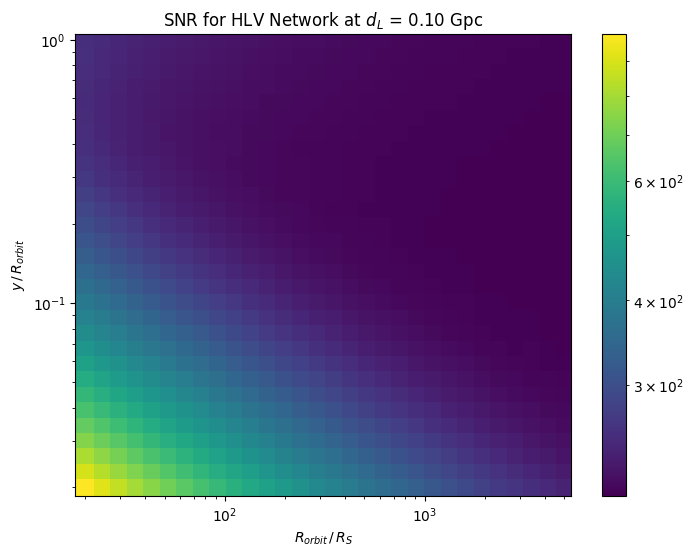

In [4]:
HLV_AGN_SNR_max = HLV_AGN.SNR({key: values[:, :, 0] for key, values in events.items()})
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.pcolormesh(R_orbit_array, src_pos_array, HLV_AGN_SNR_max, 
                   norm=LogNorm()
                   )
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,/\,R_{orbit}$')
ax.set_title(r'SNR for HLV Network at $d_L$ = {:.2f} Gpc'.format(dL_array[0]))

In [5]:
import numpy as onp
from skimage.measure import marching_cubes
import pyvista as pv

In [6]:
general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = onp.asarray(general_event_params['relative_mass'])
print(delta_iota.max(), delta_iota.min(), delta_iota.mean())
print(relative_mass.max(), relative_mass.min(), relative_mass.mean())

0.4966709076873439 8.95379059748791e-05 0.04417779310571644
1.1076886202566973 1.0000569884127168 1.0175045788420827


In [7]:
n = 30
shape = n**3
events_flat = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events_flat = {key: val.astype(np.float64) for key, val in events_flat.items()}

In [8]:
n_point = 30
r_min, r_max = 20, 5000  # R_Sch
y_min, y_max = 0.02, 0.99  # R_orbit
d_min, d_max = 0.01, 10  # Gpc
xscale = 5000
zscale = 10

grid = pv.ImageData(
    dimensions=(n_point, n_point, n_point),
    spacing=(
        (r_max - r_min) / (n_point - 1) / xscale, 
        (y_max - y_min) / (n_point - 1), 
        (d_max - d_min) / (n_point - 1) / zscale
    ),
    origin=(r_min / xscale, y_min, d_min / zscale)
)

r_mesh, y_mesh, d_mesh = grid.points.T
r_mesh *= xscale
d_mesh *= zscale

events_flat['R_orbit'] = r_mesh
events_flat['src_pos'] = y_mesh
events_flat['dL'] = d_mesh

general_event_params = L1_AGN.convert_to_general_lensed_parameters(events_flat)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = onp.asarray(general_event_params['relative_mass'])
print(delta_iota.max(), delta_iota.min(), delta_iota.mean())
print(relative_mass.max(), relative_mass.min(), relative_mass.mean())

0.4966709076873439 8.953790597376887e-05 0.006380117284688576
1.1076871296843902 1.0000569884127164 1.0040511719748157


In [9]:
out = grid.contour(
    [1e-4, 1e-3, 1e-2, 1e-1],
    scalars=delta_iota,
    method='flying_edges',
)

plotter = pv.Plotter()
plotter.enable_anti_aliasing('ssaa', multi_samples=32)
plotter.add_mesh(out, log_scale=True, opacity=0.7, show_edges=True, 
                 scalar_bar_args={'vertical': True, 
                                  'title': 'delta_iota (rad)',
                                  'position_x': 0.85})

plotter.show_bounds(
    xtitle=f'R_orbit / ({xscale:d} R_Sch)',
    ytitle='y / R_orbit',
    ztitle=f'dL / 10 Gpc',
    grid='front',
    location='outer',
    all_edges=True
)

plotter.show()

Widget(value='<iframe src="http://localhost:57271/index.html?ui=P_0x11ad114e0_0&reconnect=auto" class="pyvista…

In [10]:
out = grid.contour(
    [1.0004, 1.0005, 1.002, 1.01, 1.1],
    scalars=relative_mass,
    method='flying_edges',
)

plotter = pv.Plotter()
plotter.enable_anti_aliasing('ssaa', multi_samples=32)
plotter.add_mesh(out, log_scale=True, opacity=0.7, show_edges=True, 
                 scalar_bar_args={'vertical': True, 
                                  'title': 'relative mass',
                                  'position_x': 0.85})

plotter.show_bounds(
    xtitle=f'R_orbit / ({xscale:d} R_Sch)',
    ytitle='y / R_orbit',
    ztitle=f'dL / 10 Gpc',
    grid='front',
    location='outer',
    all_edges=True
)

plotter.show()

Widget(value='<iframe src="http://localhost:57271/index.html?ui=P_0x11a7937c0_1&reconnect=auto" class="pyvista…